In [2]:
import numpy as np
import pandas as pd
import torch
from torch import nn

In [1]:
from torch.autograd import Variable

In [3]:
torch.cuda.is_available()

True

In [4]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

<font size=3>
Given the PDE:  
$$\frac{du}{dx}  = 2 \frac{du}{dt} + u$$

The boundary condition:  
$$u(x,0) = 6e^{-3x}$$
    

<font size=3>
We consider Net as our solution $u_{\theta}(x,t)$

In [5]:
class Net(nn.Module):
    def __init__(self):
        """
        When forming the network, we have to keep in mind the number of inputs and outputs
        In ur case: #inputs = 2 (x,t)
        and #outputs = 1

        You can add ass many hidden layers as you want with as many neurons.
        More complex the network, the more prepared it is to find complex solutions, but it also requires more data.

        Let us create this network:
        min 5 hidden layer with 5 neurons each.
        """
        super(Net, self).__init__()
        self.net =  nn.Sequential(
            nn.Linear(2,5),
            nn.ReLU(),
            nn.Linear(5,5),
            nn.ReLU(),
            nn.Linear(5,5),
            nn.Sigmoid(),
            nn.Linear(5,1),
            )
        
    def forward(self, x, t):
        inputs = torch.cat([x,t], axis=1)
        output = self.net(inputs)
        return output

In [6]:
### (2) Model
u_theta = Net()
u_theta = u_theta.to(device)
mse_cost_function = torch.nn.MSELoss()    
optimizer = torch.optim.Adam(u_theta.parameters())

The PDE as loss function. Thus would use the network which we call as u_theta

In [7]:
def f(x, t, net):
    
    # the dependent variable u is given by the network based on independent variables x,t
    u = net(x,t)
    
    ## Based on our f = du/dx - 2du/dt - u, we need du/dx and du/dt
    dudx = torch.autograd.grad(u.sum(), x, create_graph=True)[0]
    dudt = torch.autograd.grad(u.sum(), t, create_graph=True)[0]
    pde = dudx - 2*dudt -u 
    
    return pde

<font size=3> The Boundary Conditions

In [8]:
from scipy.stats import norm
from matplotlib import pyplot as plt

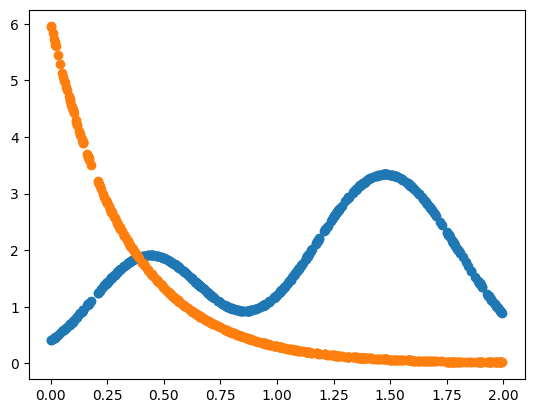

In [9]:
x_bc = np.random.uniform(low=0.0, high=2.0, size=(500,1))


# peak 1
x_bc1 = x_bc / 2 * 11.5 - 2.5
y_bc1 = norm.pdf(x_bc1) **0.5 * 3
# peak 2
x_bc2 = x_bc / 2 * 11.5 - 8.5
y_bc2 = norm.pdf(x_bc2) **0.3 * 4.4

# boundary 1
y_bc = y_bc1 + y_bc2
t_bc1 = np.ones((500, 1))


## BC just gives us dataponts for training
# u(x,0) = 6e^(-3)
# boundary 2

u_bc = 6 * np.exp( -3 * x_bc )
t_bc0 = np.zeros((500, 1))

plt.scatter(x_bc, y_bc)
plt.scatter(x_bc, u_bc)

In [10]:
t_bc0 = np.zeros((500, 1))
t_bc1 = np.ones((500, 1))

In [11]:
### Training and Fitting

iterations = 20000
previous_validation_loss = 99999

for epoch in range(iterations):
    
    optimizer.zero_grad() # to maket the gradients zero
    
    # Loss based on boundary conditions
    pt_x_bc = Variable(torch.from_numpy(x_bc).float(), requires_grad=False).to(device)
    pt_u_bc1 = Variable(torch.from_numpy(y_bc).float(), requires_grad=False).to(device)
    pt_t_bc1 = Variable(torch.from_numpy(t_bc0).float(), requires_grad=False).to(device)

    pt_t_bc0 = Variable(torch.from_numpy(t_bc0).float(), requires_grad=False).to(device)
    pt_u_bc0 = Variable(torch.from_numpy(u_bc).float(), requires_grad=False).to(device)
    
    net_bc_out0 = u_theta(pt_x_bc, pt_t_bc0) 
    mse_b0 = mse_cost_function(net_bc_out0, pt_u_bc0)    # loss B

    net_bc_out1 = u_theta(pt_x_bc, pt_t_bc1) 
    mse_b1 = mse_cost_function(net_bc_out1, pt_u_bc1)    # loss B
    
    # Loss based on PDE
    x_collocation = np.random.uniform(low=0.0, high=2.0, size=(500,1))
    t_collocation = np.random.uniform(low=0.0, high=1.0, size=(500,1))
    all_zeros = np.zeros((500,1))
    
    pt_x_collocation = Variable(torch.from_numpy(x_collocation).float(), requires_grad=True).to(device)
    pt_t_collocation = Variable(torch.from_numpy(t_collocation).float(), requires_grad=True).to(device)
    pt_all_zeros = Variable(torch.from_numpy(all_zeros).float(), requires_grad=False).to(device)
    
    f_out = f(pt_x_collocation, pt_t_collocation, u_theta) # output of collocation points
    mse_f = mse_cost_function(f_out, pt_all_zeros)
    
    # Combining the loss functions
    loss = mse_b0 + mse_b1 + mse_f
    
    loss.backward()
    optimizer.step()
    
    with torch.autograd.no_grad():
        print(epoch, "Training Loss:", loss.data)

0 Training Loss: tensor(6.6451, device='cuda:0')
1 Training Loss: tensor(6.6231, device='cuda:0')
2 Training Loss: tensor(6.6013, device='cuda:0')
3 Training Loss: tensor(6.5796, device='cuda:0')
4 Training Loss: tensor(6.5579, device='cuda:0')
5 Training Loss: tensor(6.5365, device='cuda:0')
6 Training Loss: tensor(6.5151, device='cuda:0')
7 Training Loss: tensor(6.4938, device='cuda:0')
8 Training Loss: tensor(6.4728, device='cuda:0')
9 Training Loss: tensor(6.4519, device='cuda:0')
10 Training Loss: tensor(6.4308, device='cuda:0')
11 Training Loss: tensor(6.4103, device='cuda:0')
12 Training Loss: tensor(6.3896, device='cuda:0')
13 Training Loss: tensor(6.3691, device='cuda:0')
14 Training Loss: tensor(6.3489, device='cuda:0')
15 Training Loss: tensor(6.3286, device='cuda:0')
16 Training Loss: tensor(6.3086, device='cuda:0')
17 Training Loss: tensor(6.2886, device='cuda:0')
18 Training Loss: tensor(6.2688, device='cuda:0')
19 Training Loss: tensor(6.2490, device='cuda:0')
20 Trainin

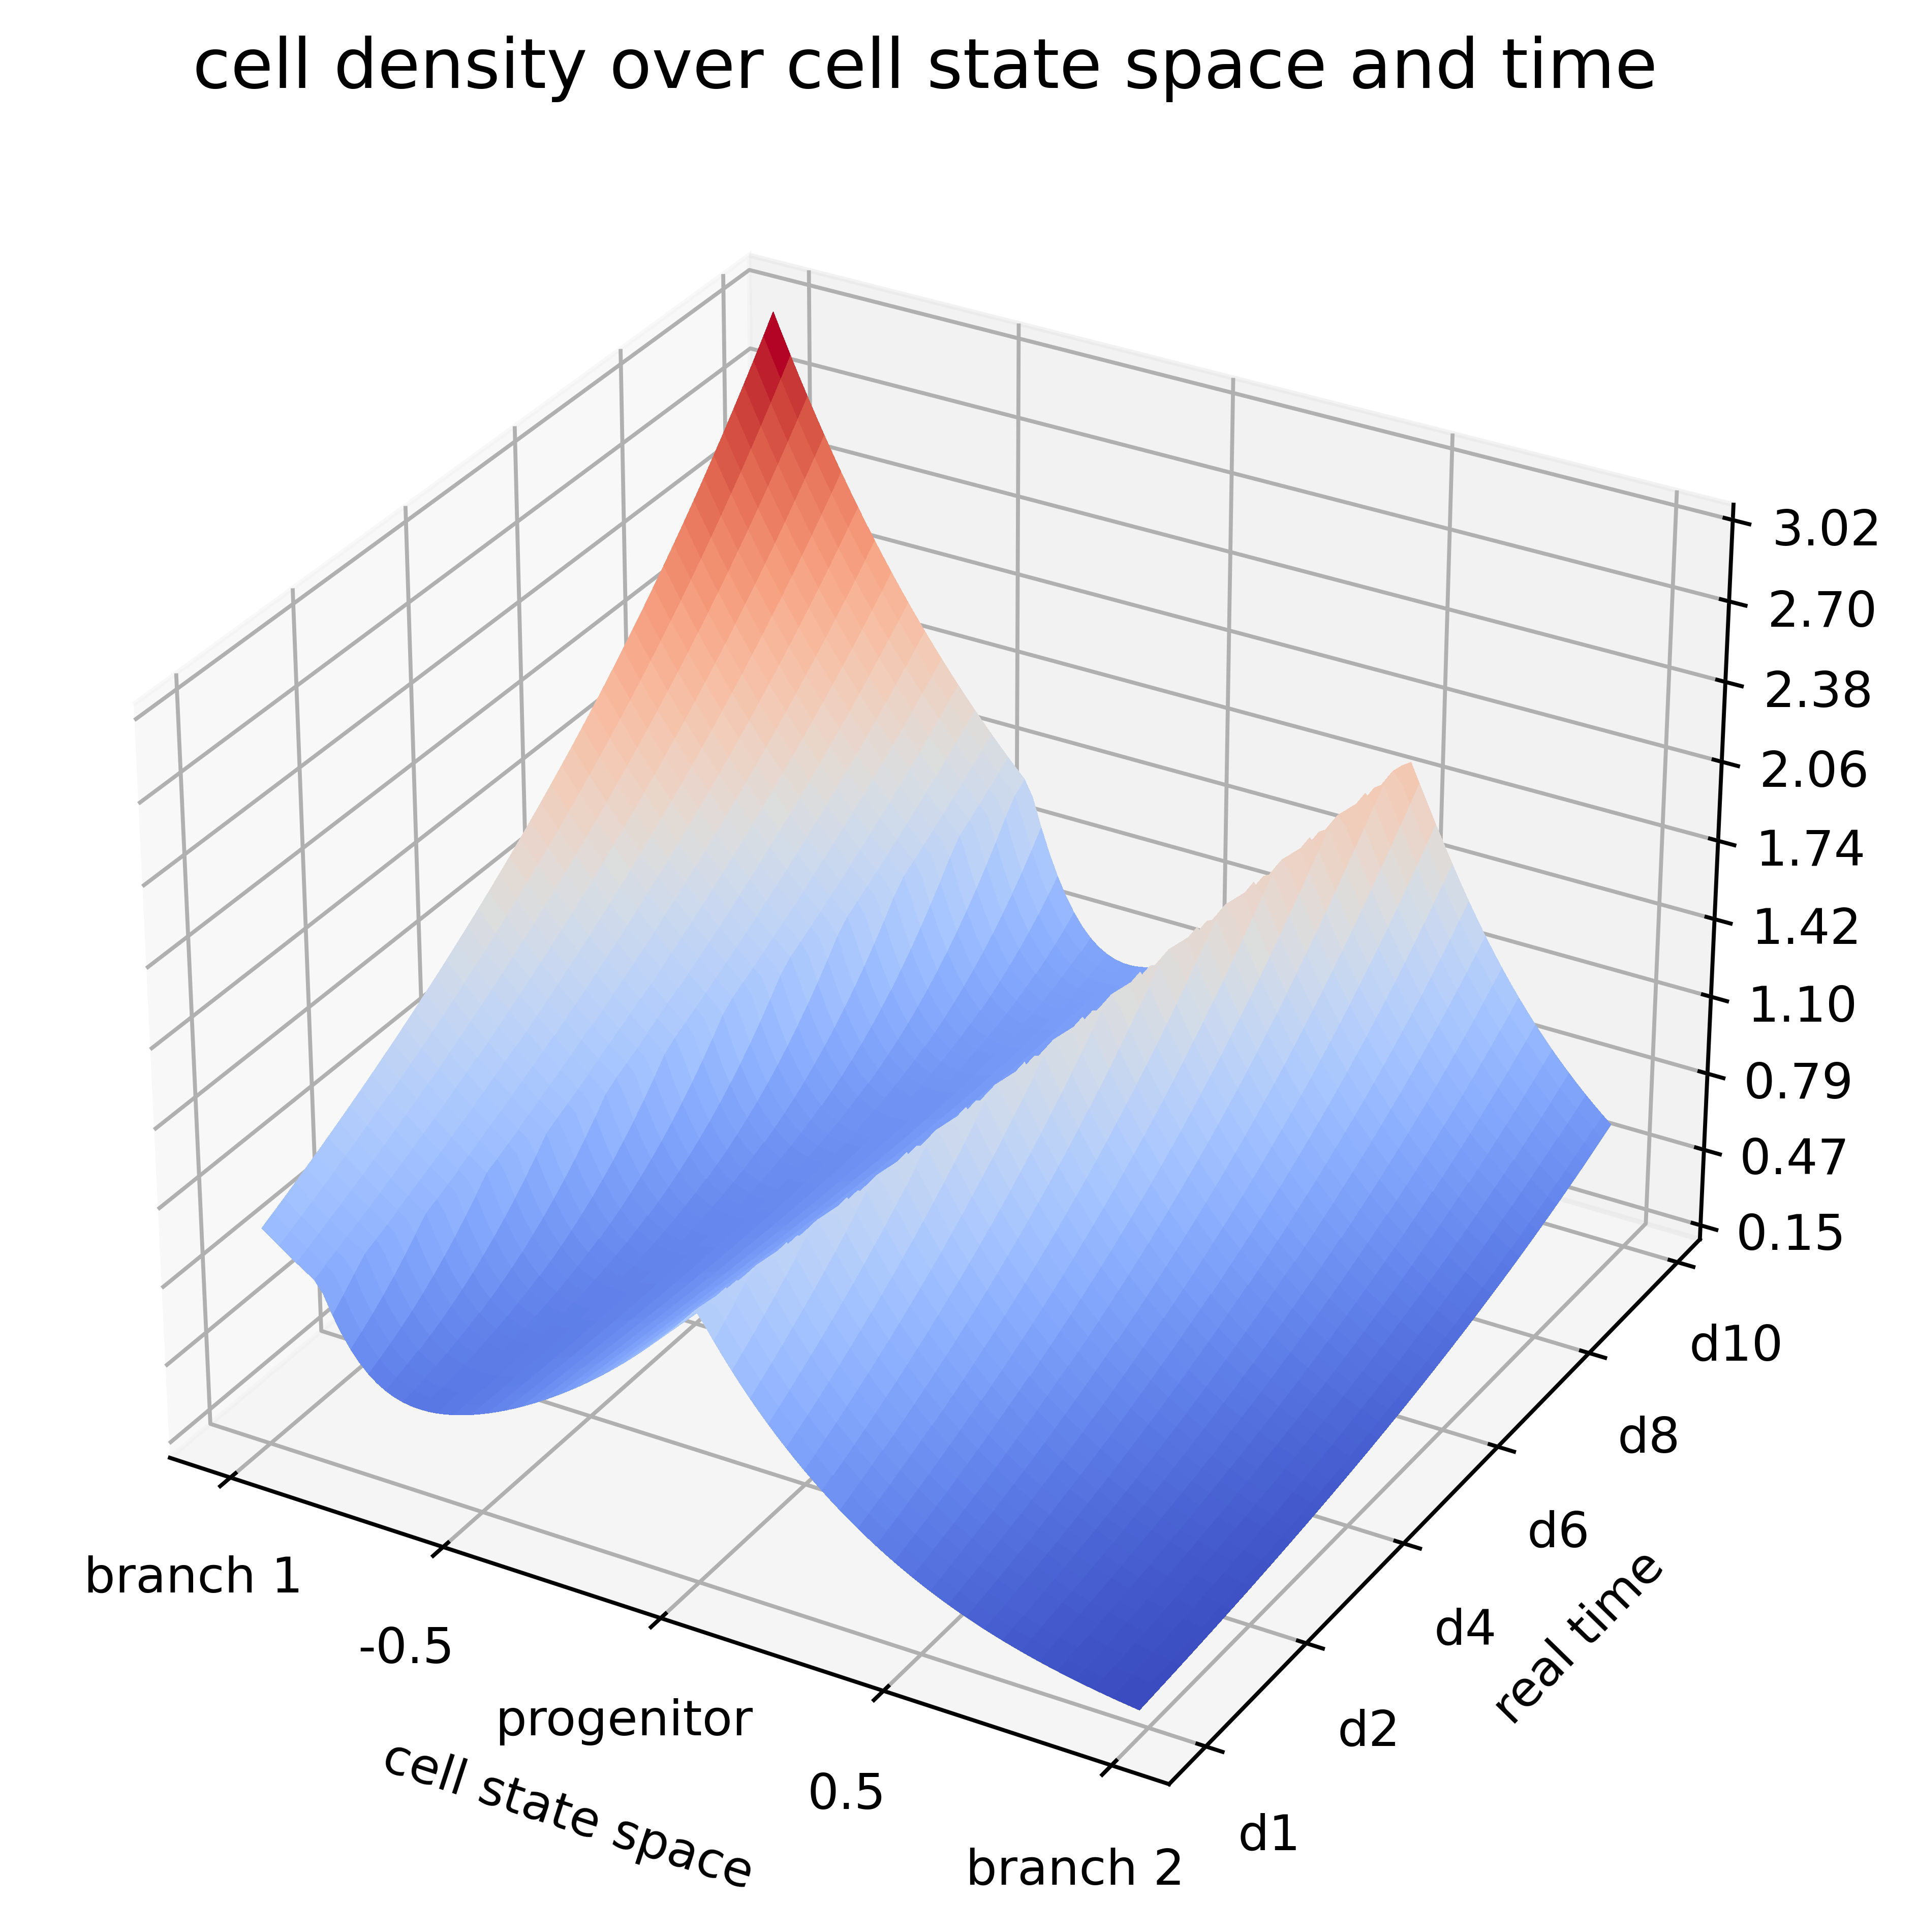

In [55]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
import numpy as np

fig = plt.figure(figsize=(14,5), dpi=700)

ax = fig.add_axes([0, 0, 0.7, 1], projection='3d')


x=np.arange(0,2,0.02)
t=np.arange(0,1,0.02)
ms_x, ms_t = np.meshgrid(x, t)
## Just because meshgrid is used, we need to do the following adjustment
x = np.ravel(ms_x).reshape(-1,1)
t = np.ravel(ms_t).reshape(-1,1)

pt_x = Variable(torch.from_numpy(x).float(), requires_grad=True).to(device)
pt_t = Variable(torch.from_numpy(t).float(), requires_grad=True).to(device)
pt_u = u_theta(pt_x,pt_t)
u = pt_u.data.cpu().numpy()
ms_u = u.reshape(ms_x.shape)

surf = ax.plot_surface(ms_x,ms_t,ms_u[::-1], cmap=cm.coolwarm,linewidth=0, antialiased=False)
             

ax.set_xlabel('\ncell state space')
ax.set_xticks([0, 0.5, 1, 1.5,  2])
ax.set_xticklabels(['branch 1', '-0.5', 'progenitor', '0.5', 'branch 2'])


ax.set_ylabel('real time')
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['d1', 'd2', 'd4', 'd6', 'd8', 'd10'])

ax.zaxis.set_major_locator(LinearLocator(10))
ax.zaxis.set_major_formatter(FormatStrFormatter('%.02f'))

# cbar = plt.colorbar(surf, shrink=0.3, aspect=4)
# cbar.ax.set_title('cell density')

ax.set_title('cell density over cell state space and time', fontsize=14)

plt.show()

In [15]:
ms_u[::-1].shape

(50, 100)